In [1]:
import onep
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from cebra import CEBRA, plot_loss, plot_embedding


ModuleNotFoundError: No module named 'pykalman'

In [156]:
traces = onep.InscopixProcessing(session="recall", animal="astro4", data_directory=r"C:\Users\ryansenne\Desktop")
traces.read_inscopix()

In [157]:
behavioral_data = pd.read_csv(r"C:\Users\ryansenne\Desktop\test.csv")

In [158]:
len(behavioral_data)

5399

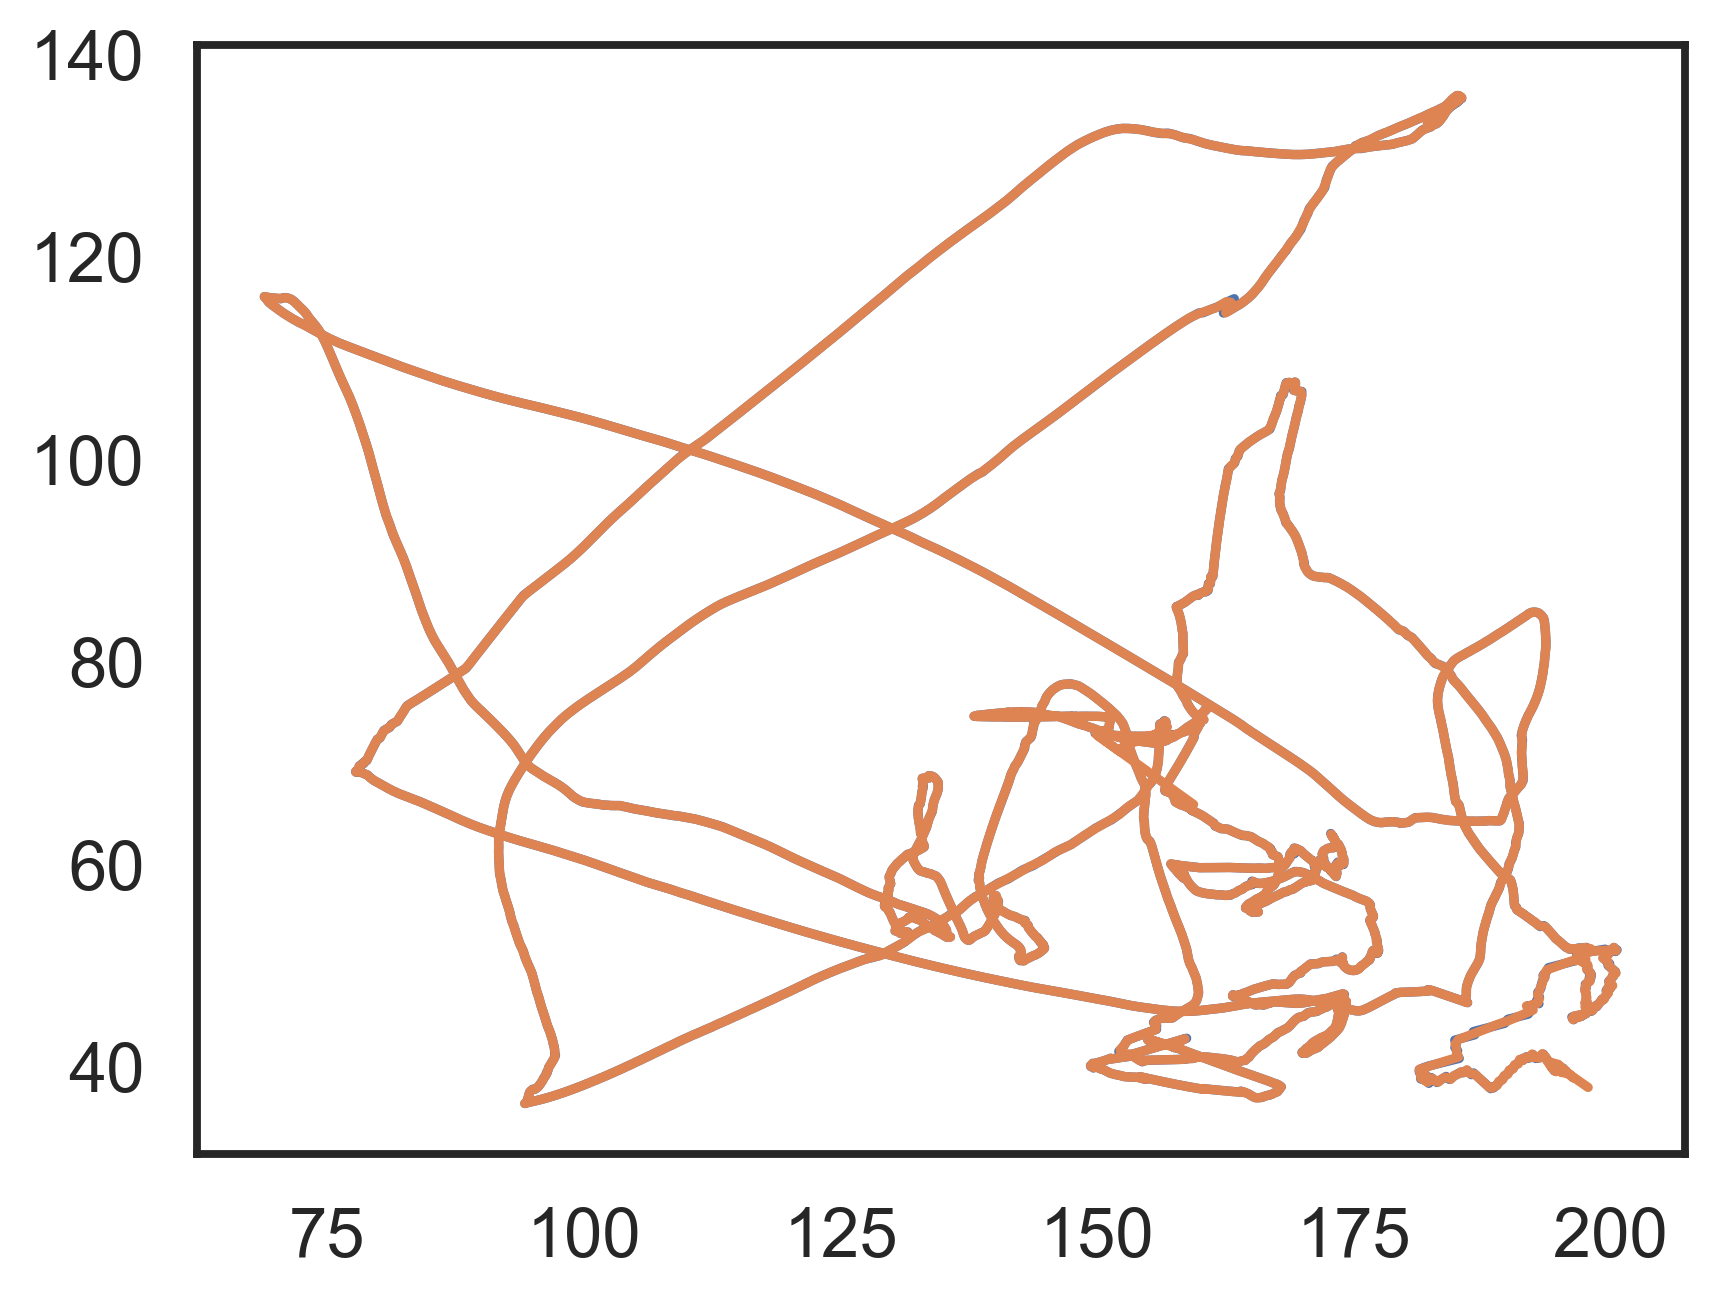

In [159]:
plt.plot(behavioral_data.iloc[:, 1], behavioral_data.iloc[:, 2])
plt.plot(resample(behavioral_data.iloc[:, 1], 3602), resample(behavioral_data.iloc[:, 2], 3602))


In [160]:
max_iterations = 10000
output_dimension = 10
cebra_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=max_iterations,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

embedding = cebra_model.fit_transform(traces.accepted_traces, resample(behavioral_data.iloc[:, 1:], 3602))



pos:  0.0981 neg:  5.4086 total:  5.5067 temperature:  1.0000: 100%|██████████| 10000/10000 [18:21<00:00,  9.08it/s] 


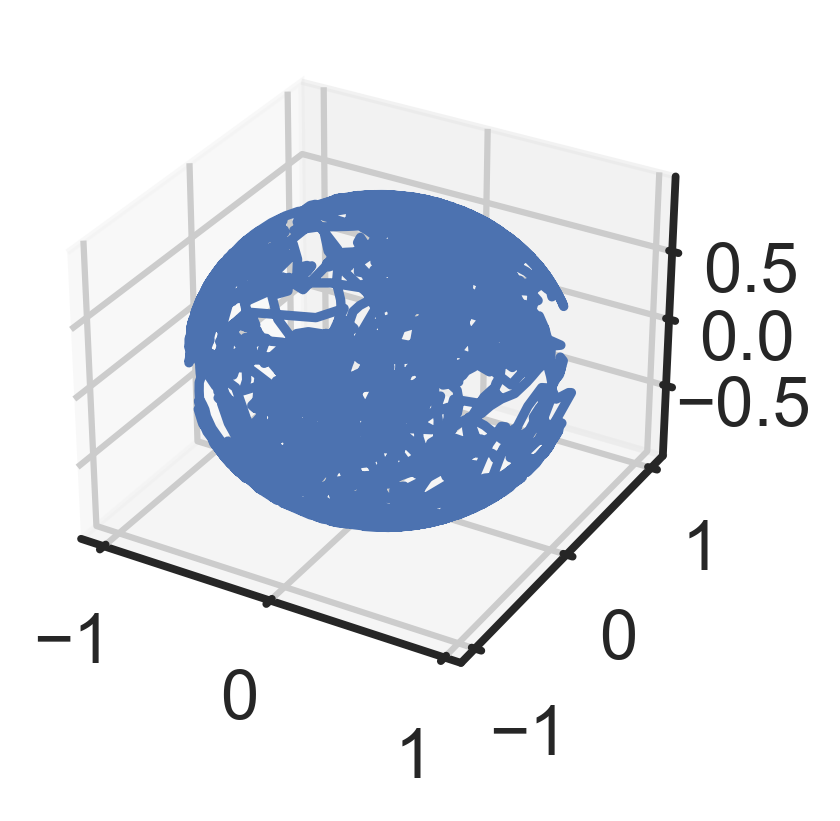

In [172]:
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(embedding[:, 0], embedding[:, 1], embedding[:, 2])

In [173]:
from sklearn.model_selection import train_test_split
from scipy.signal import resample

X_train, X_test, Y_train, Y_test = train_test_split(embedding, resample(behavioral_data.iloc[:, 1:], 3602))


In [174]:
from sklearn.metrics import r2_score
import cebra
def decoding_pos_dir(embedding_train, embedding_test, label_train, label_test):
   pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
   dir_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")

   pos_decoder.fit(embedding_train, label_train[:,0])
   dir_decoder.fit(embedding_train, label_train[:,1])

   pos_pred = pos_decoder.predict(embedding_test)
   dir_pred = dir_decoder.predict(embedding_test)

   prediction = np.stack([pos_pred, dir_pred],axis = 1)

   test_score = r2_score(label_test[:,:2], prediction)
   pos_test_err = np.median(abs(prediction[:,0] - label_test[:, 0]))
   pos_test_score = r2_score(label_test[:, 0], prediction[:,0])

   return test_score, pos_test_err, pos_test_score

decoding_pos_dir(X_train, X_test, Y_train, Y_test)

(0.5527633889328825, 5.346360814750454, 0.5509035111371079)

In [175]:
pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
pos_decoder.fit(X_train, Y_train)



KNNDecoder(n_neighbors=36)

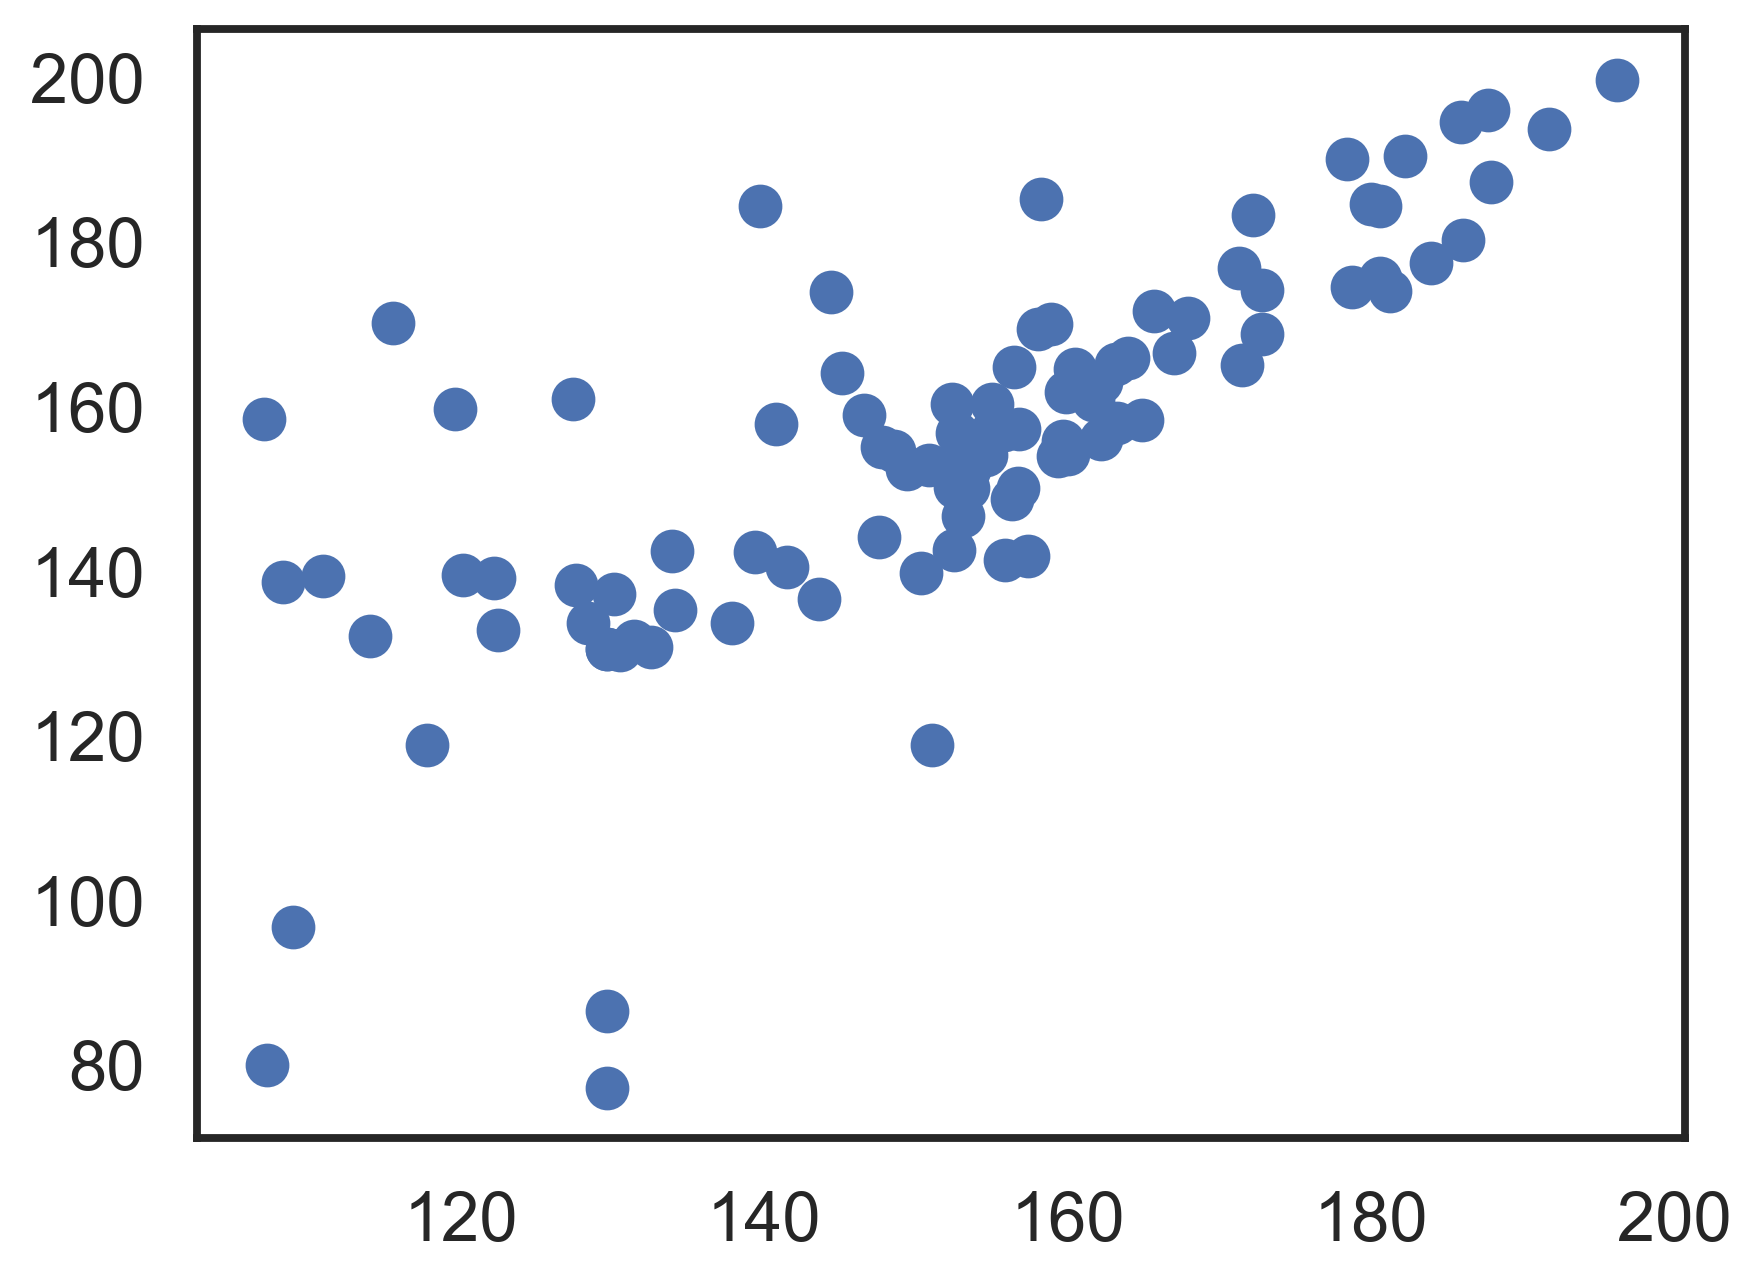

In [186]:
pred = pos_decoder.predict(X_test)
plt.scatter(pred[:100, 0], Y_test[:100, 0])

In [189]:
import statsmodels.api as sm
sm.OLS(pred[:100, 1], sm.add_constant(Y_test[:100, 1])).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     119.5
Date:                Mon, 11 Sep 2023   Prob (F-statistic):           1.16e-18
Time:                        14:35:53   Log-Likelihood:                -357.56
No. Observations:                 100   AIC:                             719.1
Df Residuals:                      98   BIC:                             724.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.7029      3.435      8.357      0.000      21.887      35.519
x1             0.5708      0.052     10.932      0.000       0.467       0.674
==============================================================================
Omnibus:                        4.040   Durbin-Watson:                   2.443
Prob(Omnibus):                  0.133   Jarque-Bera (JB):                3.533
Skew:                           0.452   Prob(JB):                        0.171
Kurtosis:                       3.176   Cond. No.                         259.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [103]:
ss = StandardScaler()
pca = PCA()
scaled_traces = ss.fit_transform(traces.accepted_traces.to_numpy())
reduced_data = pca.fit_transform(scaled_traces.T)

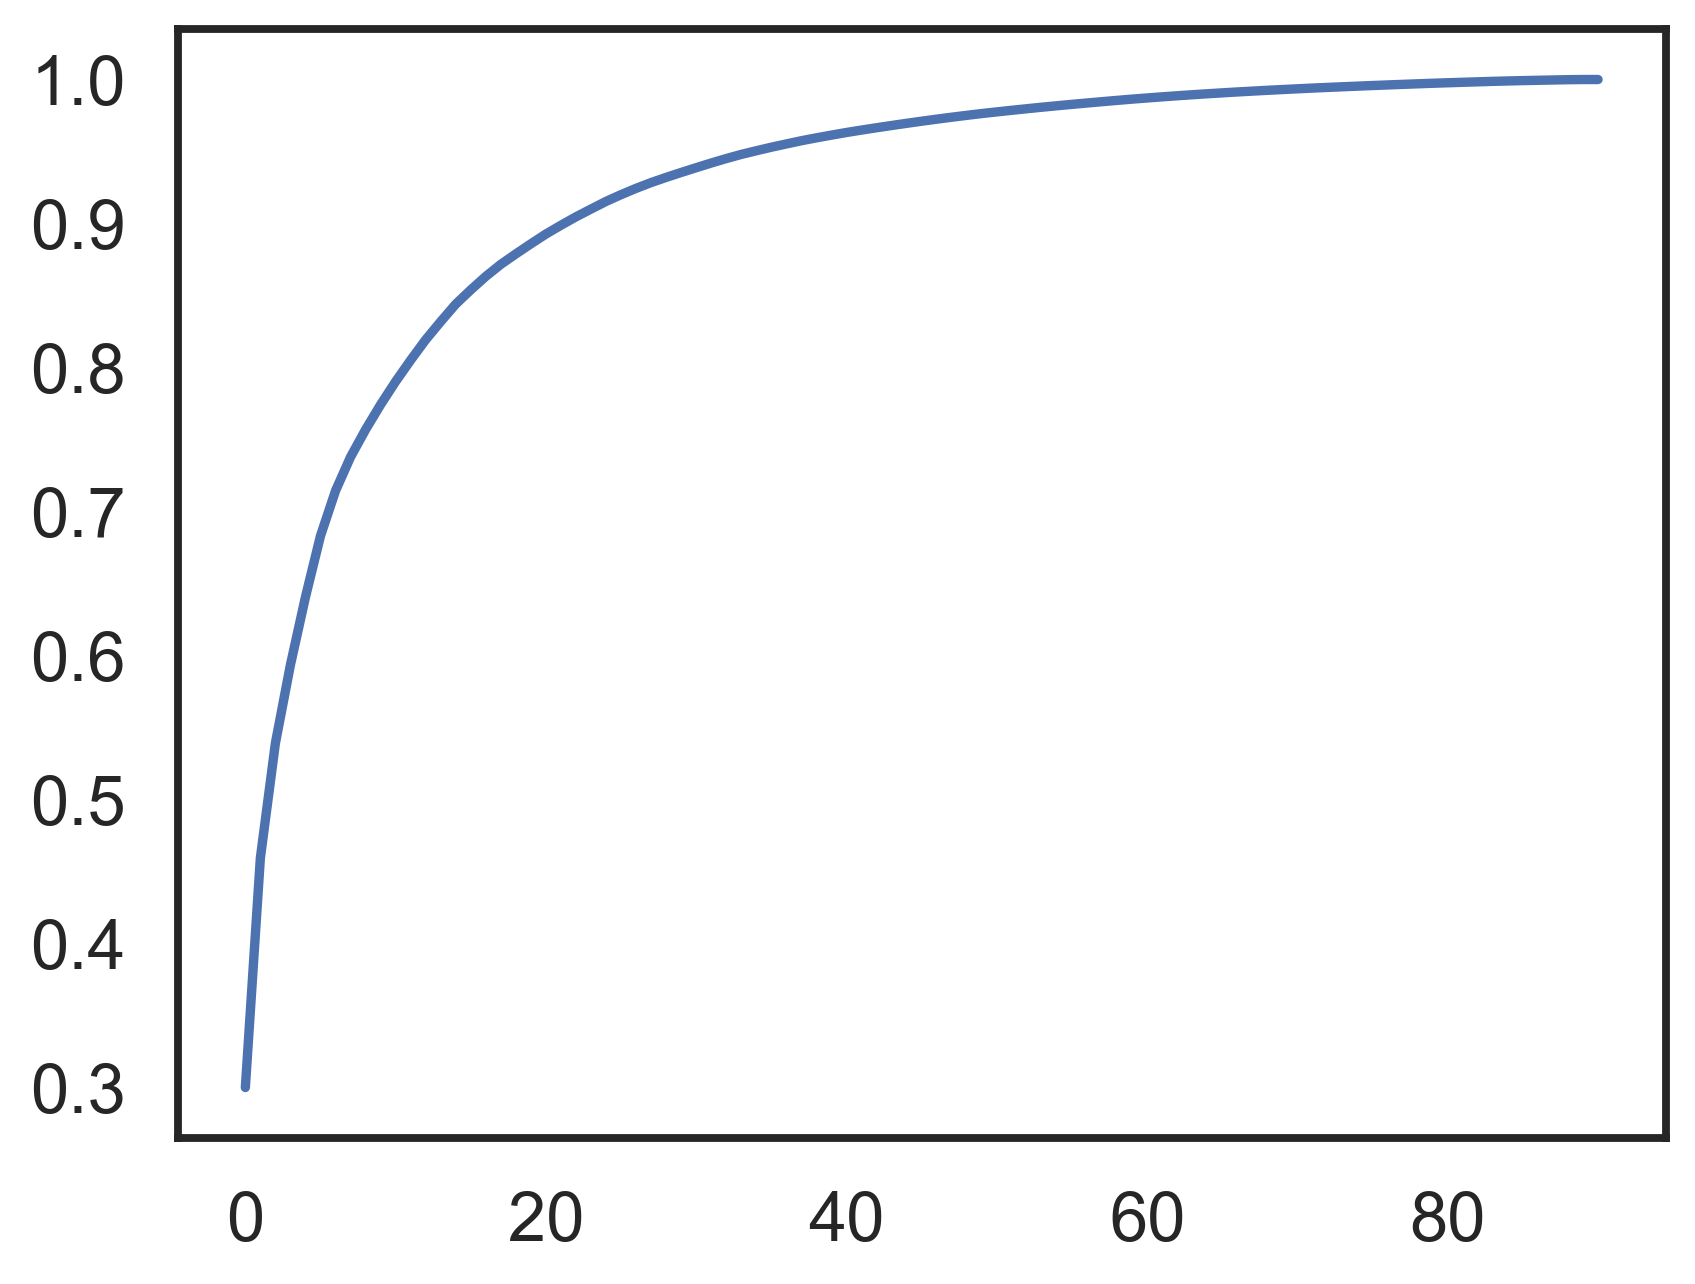

In [104]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [105]:
np.where(np.cumsum(pca.explained_variance_ratio_)>0.9)

(array([22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
        39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
        56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
        73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90], dtype=int64),)

In [66]:
dir(pca)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_check_feature_names',
 '_check_n_features',
 '_fit',
 '_fit_full',
 '_fit_svd_solver',
 '_fit_truncated',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_n_features_out',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_validate_data',
 '_validate_params',
 'components_',
 'copy',
 'explained_variance_',
 'explained_variance_ratio_',
 'fit',
 'fit_transform',
 'get_covariance',
 'get_feature_names_out',
 'get_params',
 'get_precision',
 'inverse_trans

SSM

In [42]:
import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(0)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline

import seaborn as sns

sns.set_style("white")
sns.set_context("talk")

color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)
cmap = ListedColormap(colors)

import ssm
from ssm.util import random_rotation, find_permutation
from ssm.plots import plot_dynamics_2d

save_figures = False


In [43]:
np.shape(traces.accepted)

AttributeError: 'InscopixProcessing' object has no attribute 'accepted'

In [106]:
inds = scaled_traces.shape[0]
obs_dim = scaled_traces.shape[1]
discrete_states = 3
cont_dim = 22

fc_rslds = ssm.SLDS(obs_dim,
                     discrete_states,
                     cont_dim,
                     emissions="gaussian_orthog",
                     transitions="recurrent"
                     )

q_mf_elbos, q_lem = fc_rslds.fit(scaled_traces, 
                    method="laplace_em", 
                    variational_posterior="structured_meanfield", 
                    num_iters=100, alpha=0.0)

xhat_lem = q_lem.mean_continuous_states[0]
zhat_lem = fc_rslds.most_likely_states(xhat_lem, scaled_traces)

  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

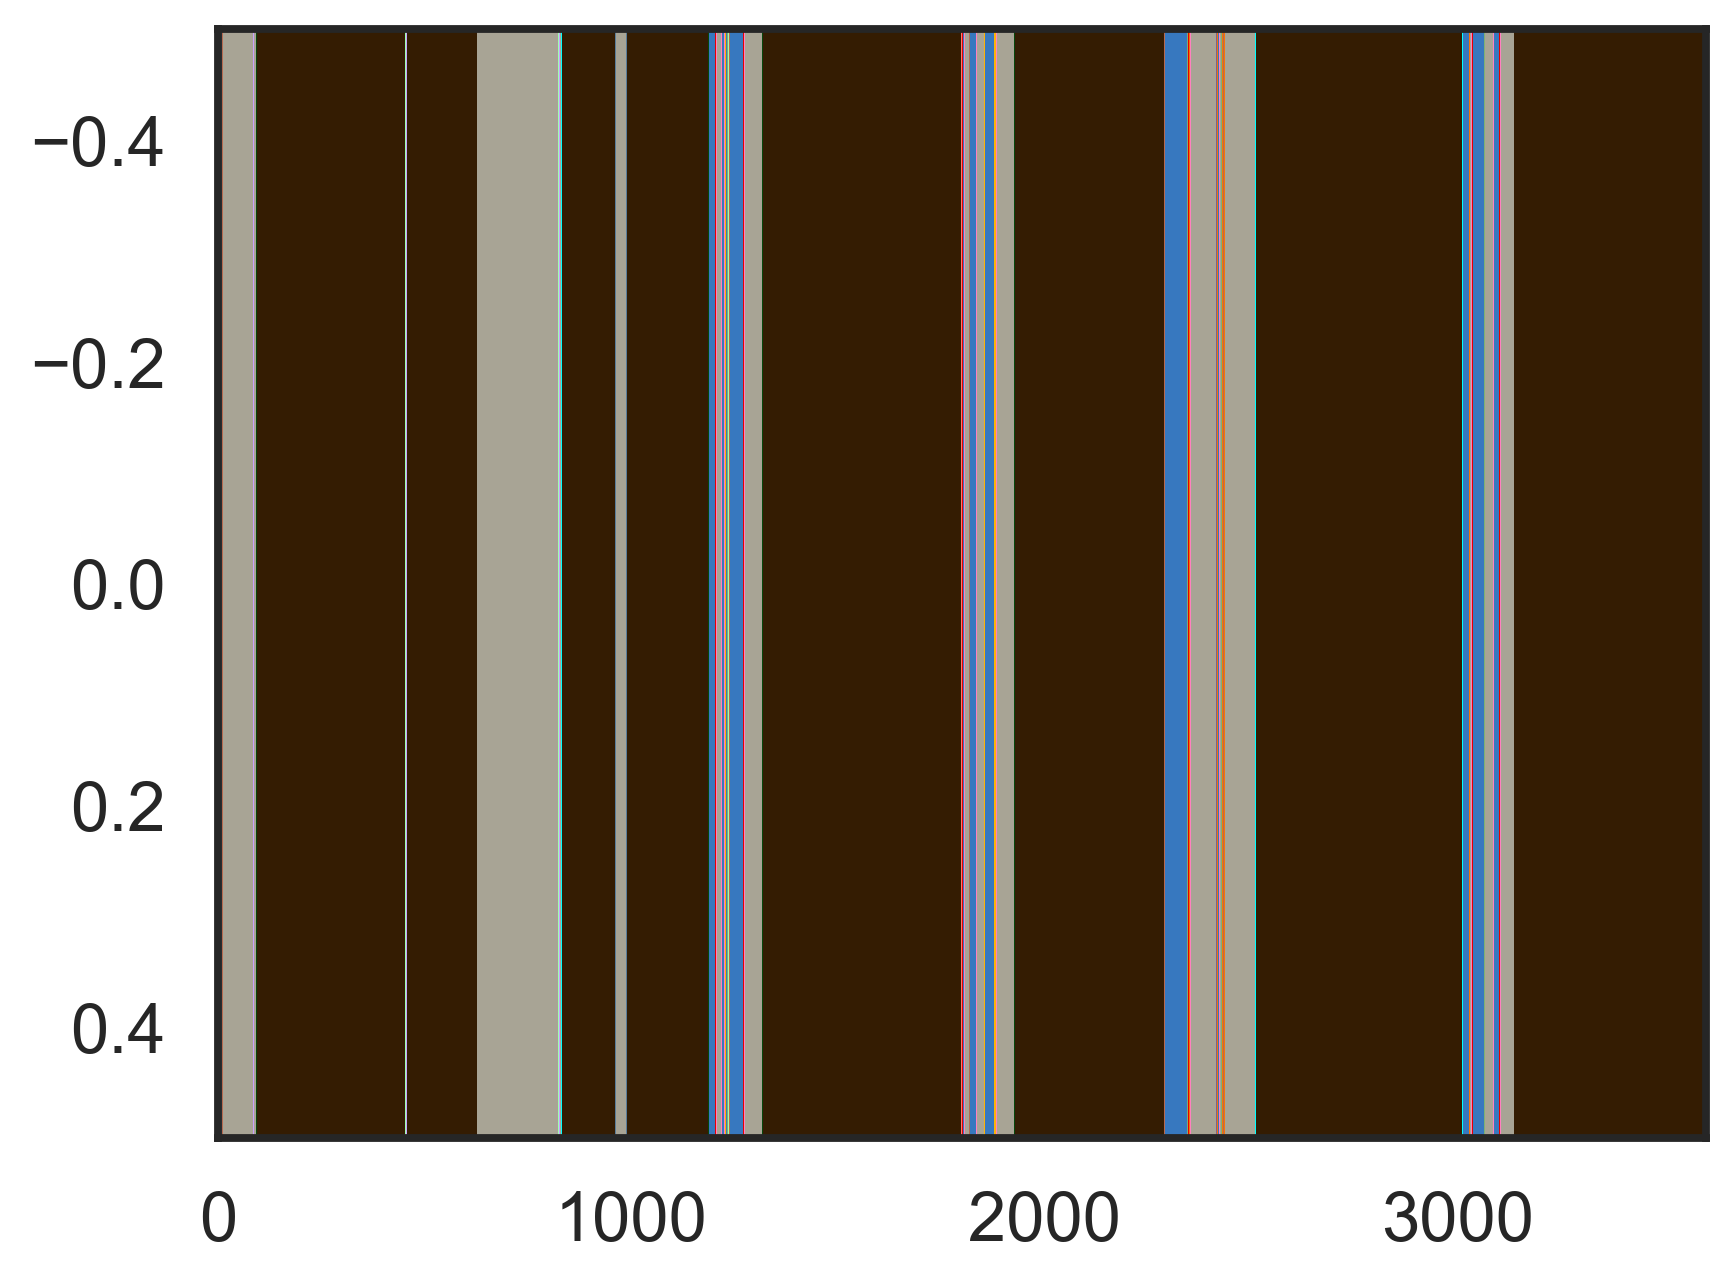

In [107]:
plt.imshow(zhat_lem.reshape(-1, 1).T, aspect="auto", cmap=cmap)

In [47]:

# Helper functions for plotting results
def plot_trajectory(z, x, ax=None, ls="-"):
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    for start, stop in zip(zcps[:-1], zcps[1:]):
        ax.plot(x[start:stop + 1, 0],
                x[start:stop + 1, 1],
                lw=1, ls=ls,
                color=colors[z[start] % len(colors)],
                alpha=1.0)
    return ax

def plot_observations(z, y, ax=None, ls="-", lw=1):

    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    T, N = y.shape
    t = np.arange(T)
    for n in range(N):
        for start, stop in zip(zcps[:-1], zcps[1:]):
            ax.plot(t[start:stop + 1], y[start:stop + 1, n],
                    lw=lw, ls=ls,
                    color=colors[z[start] % len(colors)],
                    alpha=1.0)
    return ax


def plot_most_likely_dynamics(model,
    xlim=(-4, 4), ylim=(-3, 3), nxpts=30, nypts=30,
    alpha=0.8, ax=None, figsize=(3, 3)):

    K = model.K
    # assert model.D == 2
    x = np.linspace(*xlim, nxpts)
    y = np.linspace(*ylim, nypts)
    X, Y = np.meshgrid(x, y)
    xy = np.column_stack((X.ravel(), Y.ravel()))

    # Get the probability of each state at each xy location
    log_Ps = model.transitions.log_transition_matrices(
        xy, np.zeros((nxpts * nypts, 0)), np.ones_like(xy, dtype=bool), None)
    z = np.argmax(log_Ps[:, 0, :], axis=-1)
    print(np.shape(z))
    z = np.concatenate([[z[0]], z])

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)

    for k, (A, b) in enumerate(zip(model.dynamics.As, model.dynamics.bs)):
        dxydt_m = xy.dot(A.T[:2, :2]) + b[:2] - xy[:, :2]

        zk = z == k
        print(np.shape(zk))
        print(np.shape(dxydt_m))
        print(np.shape(xy))
        if zk.sum() > 0:
            ax.quiver(xy[zk, 0], xy[zk, 1],
                      dxydt_m[zk, 0], dxydt_m[zk, 1],
                      color=colors[k % len(colors)], alpha=alpha)

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    plt.tight_layout()

    return ax


<Axes: >

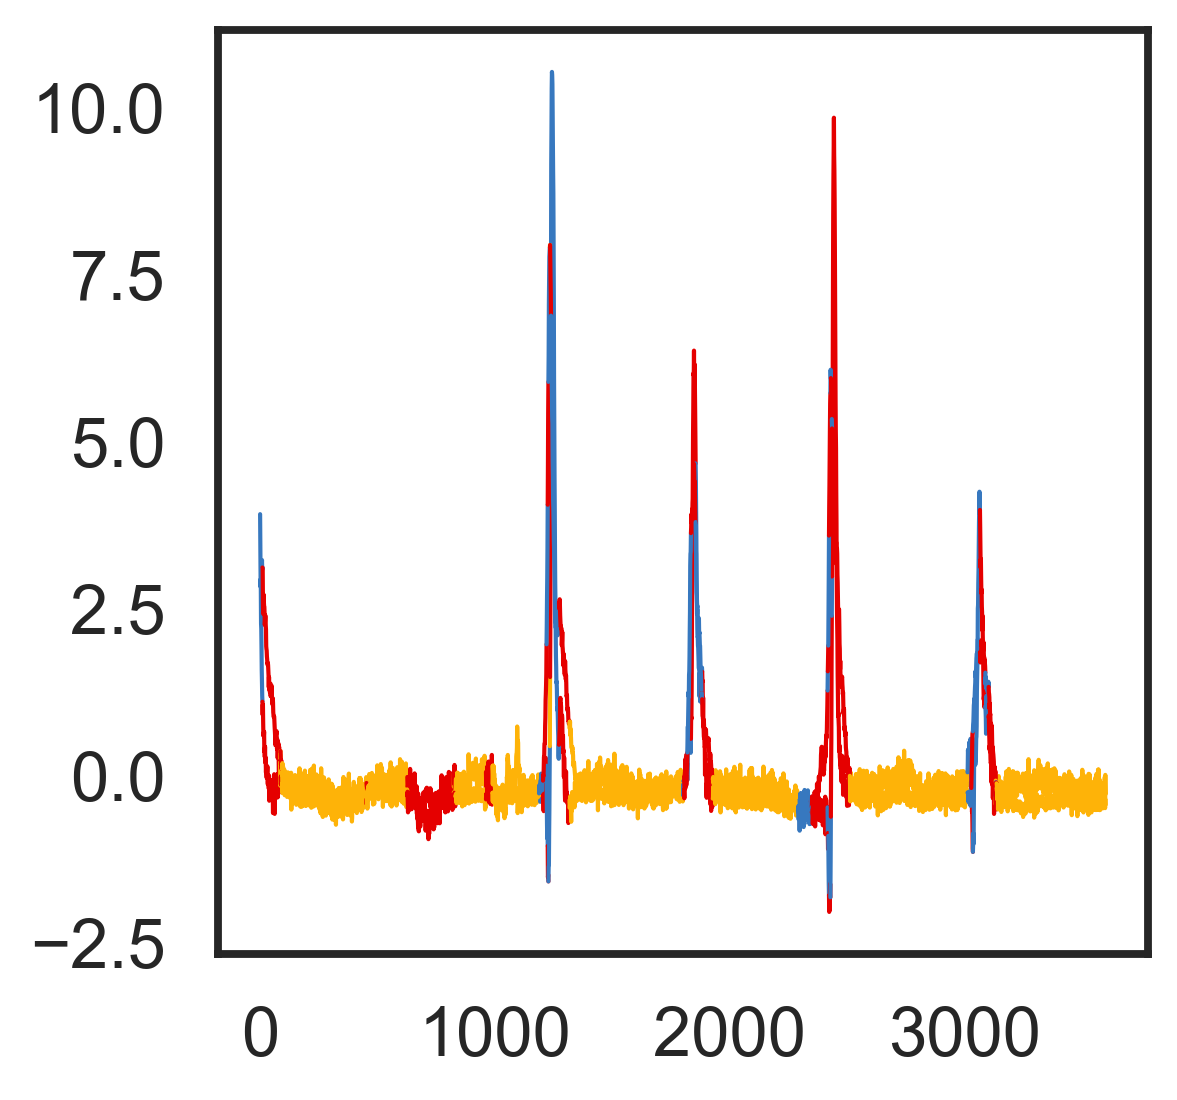

In [108]:
plot_observations(zhat_lem, scaled_traces[:, :2])

In [57]:
plot_most_likely_dynamics(fc_rslds)

ValueError: shapes (899,2) and (10,4) not aligned: 2 (dim 1) != 10 (dim 0)

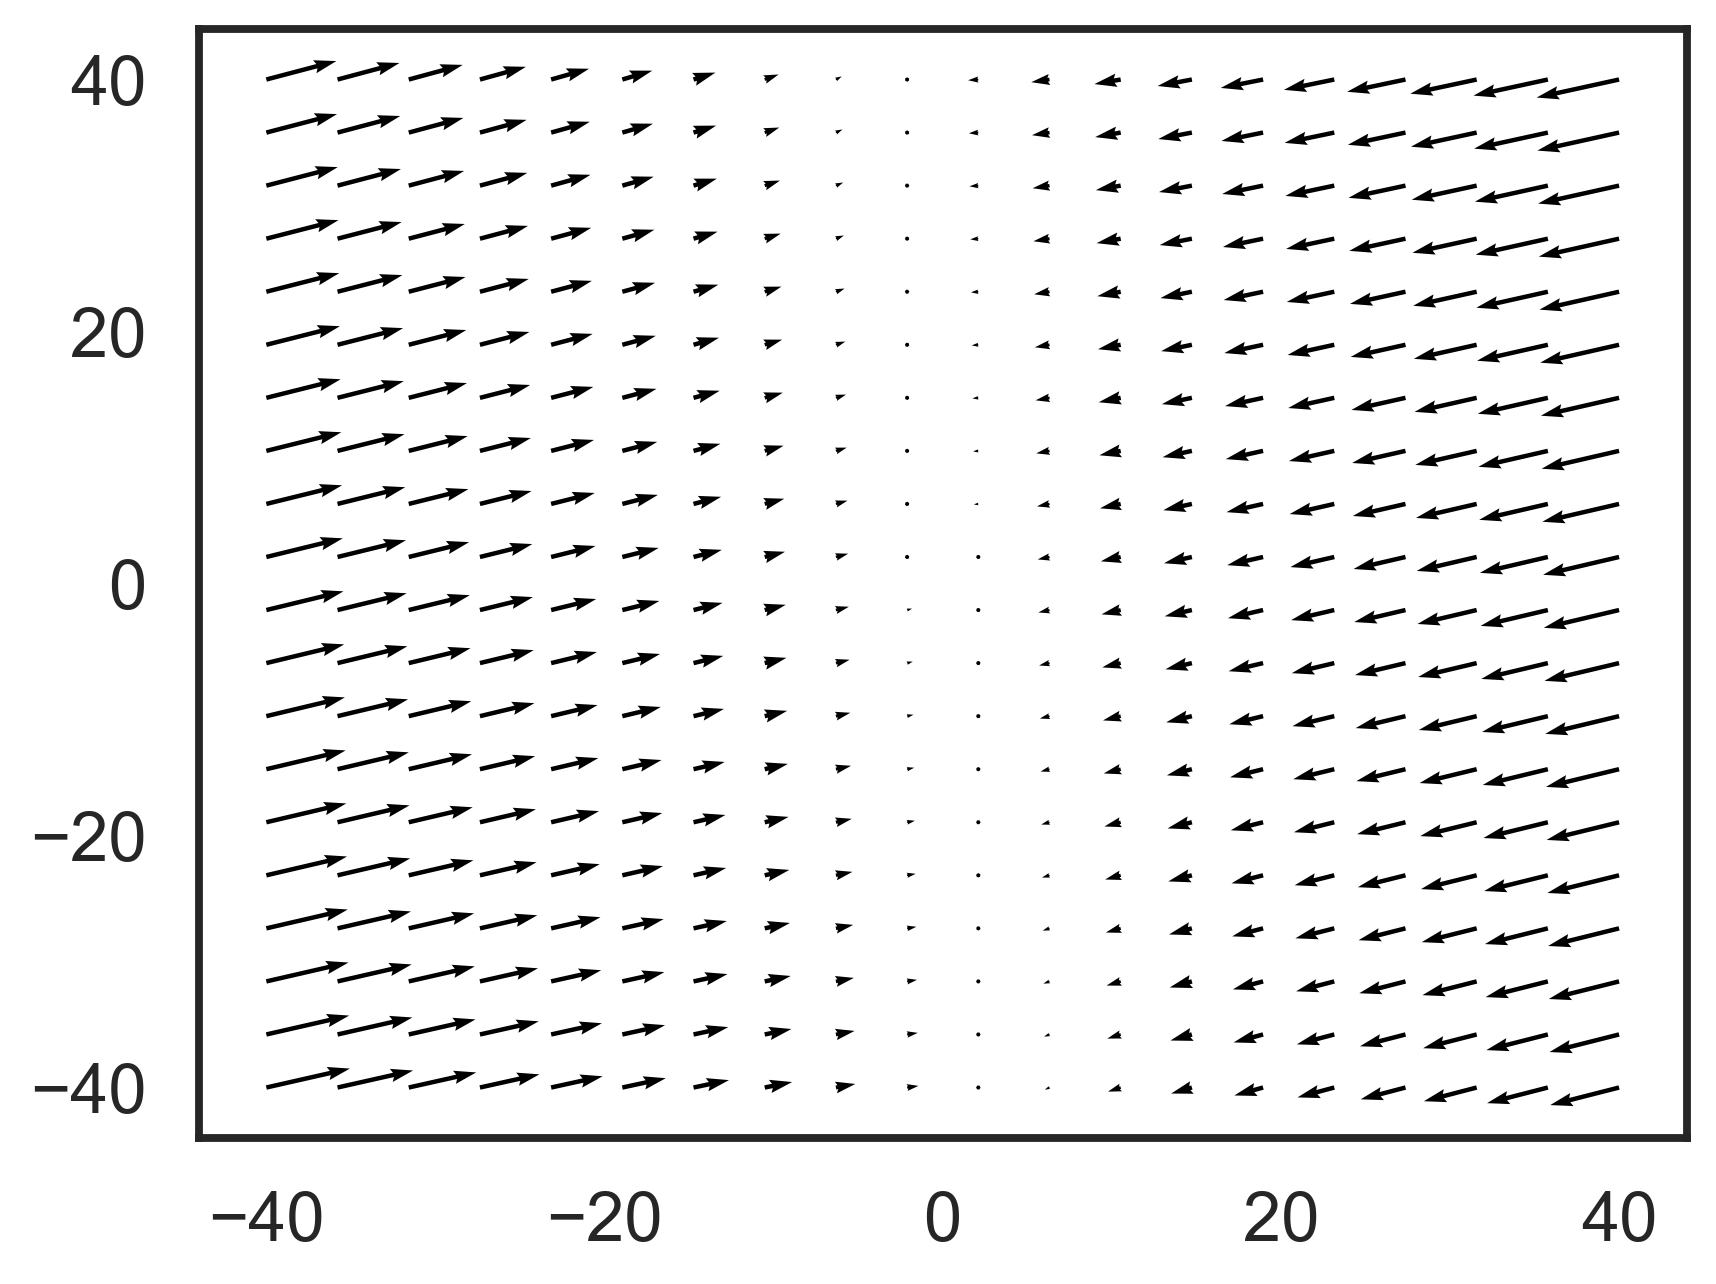

In [112]:
plot_dynamics_2d(fc_rslds.dynamics.As[0, :2, :2], fc_rslds.dynamics.bs[0, :2])

<Axes: >

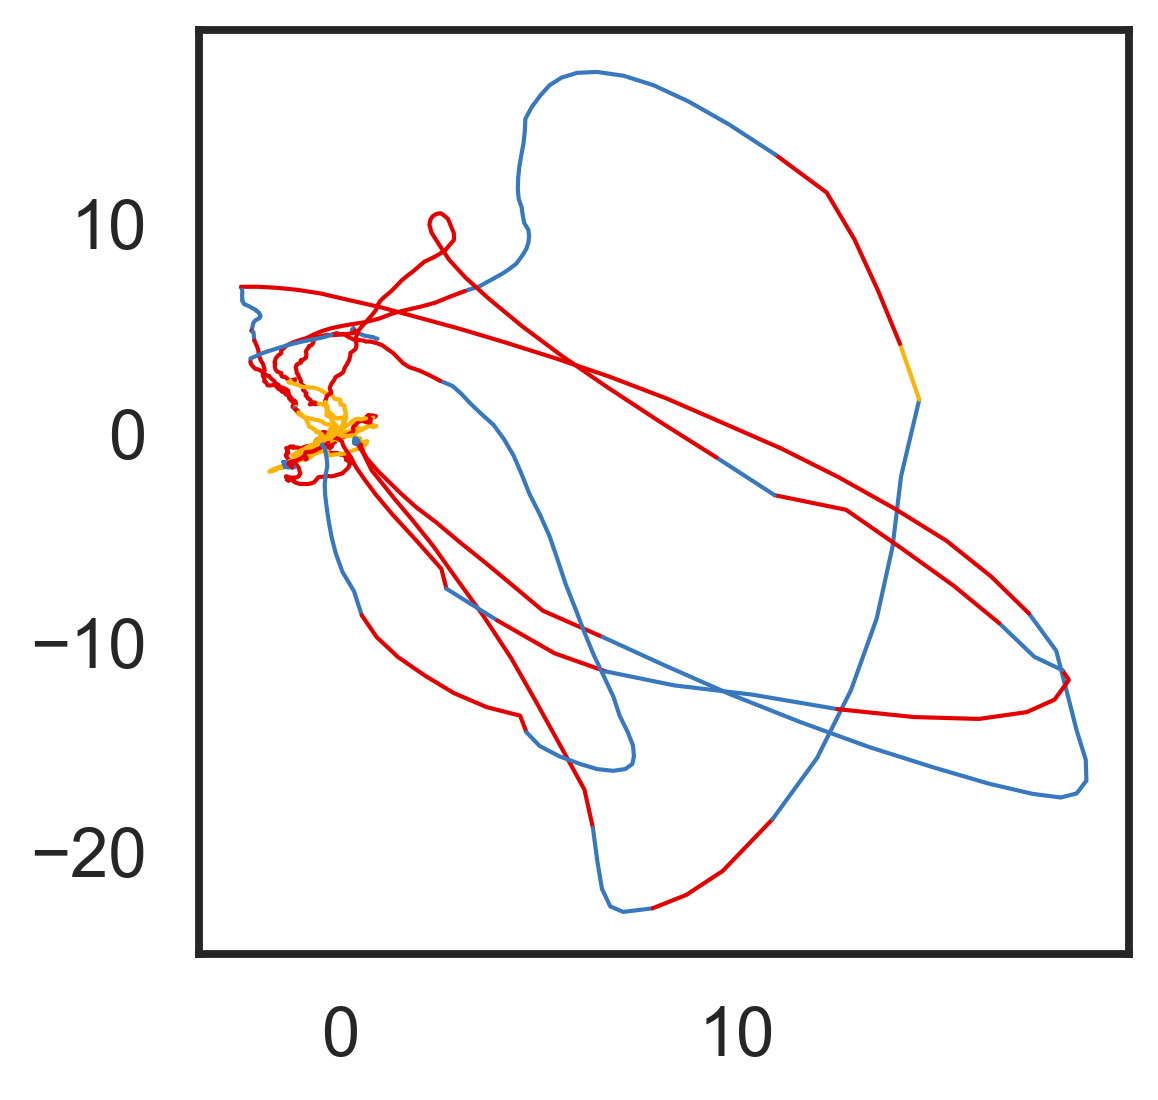

In [113]:
plot_trajectory(zhat_lem, xhat_lem)

In [ ]:
n_clusters = 20
labels = kmeans.labels_
for i in range(n_clusters):
    cluster_i_data = scaled_traces.T[labels == i]  # Extract the traces belonging to cluster i

    # Create a new figure for each cluster
    plt.figure(figsize=(10, 8))

    # Plot each trace in this cluster
    for trace in cluster_i_data:
        plt.plot(trace)

    # You might want to add some labels, title or legend here, e.g.:
    plt.title(f"Cluster {i}")
    plt.xlabel("Time")
    plt.ylabel("Trace value")

    plt.show()

In [2]:
onep.behavioral_analysis.kalman_filter()

NameError: name 'onep' is not defined